  ## Mutual Fund Performance Analysis (EDA)

**PROBLEM STATEMENT**

Making educated decisions is challenging for mutual fund investors because they often have to deal with hundreds of schemes that vary in terms of returns, risk, expense ratios, and investment constraints.

 In order to comprehend how fund category, risk metrics, fund size, expense ratio, and investment horizon affect returns and risk-adjusted performance, this project intends to conduct a thorough exploratory data analysis on mutual fund schemes.

 The study aims to figure out whether lower-cost funds outperform expensive ones, whether higher returns are consistently linked to higher risk, and whether short-term performance is a reliable predictor of long-term success.

 This project offers insights that can help with academic understanding, evidence-based fund evaluation, and investor education by fusing statistical analysis and visualization.

**Imports & Configuration**

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


Data Loading

In [ ]:
# Load dataset
path = "../data/comprehensive_mutual_funds_data.csv"
df = pd.read_csv(path)

# Preview data
df.head()


,scheme_name,min_sip,min_lumpsum,expense_ratio,fund_size_cr,fund_age_yr,fund_manager,sortino,alpha,sd,beta,sharpe,risk_level,amc_name,rating,category,sub_category,returns_1yr,returns_3yr,returns_5yr
0,Aditya Birla SL Active Debt Multi-Mgr FoF-Dir ...,100,100,0.27,10.00,10,Kaustubh Gupta,0.32,2.24,9.39,0.01,0.24,3,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,4.00,6.50,6.90
1,Aditya Birla SL Arbitrage Fund,1000,1000,0.36,4288.00,10,Lovelish Solanki,1.33,1.53,0.72,0.56,1.1,1,Aditya Birla Sun Life Mutual Fund,3,Hybrid,Arbitrage Mutual Funds,5.60,4.80,5.50
2,Aditya Birla SL Asset Allocator FoF-Dir Growth,1000,1000,0.53,157.00,10,Vinod Narayan Bhat,3.44,2.67,10.58,0.67,1.42,5,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,2.00,18.90,9.70
3,Aditya Birla SL Bal Bhavishya Yojna – Dir Growth,500,1000,0.76,637.00,4,Atul Penkar,2.18,-6.37,14.99,0.85,0.9,6,Aditya Birla Sun Life Mutual Fund,2,Solution Oriented,Childrens Funds,-0.70,17.10,NaN
4,Aditya Birla SL Balanced Advantage Fund,100,100,0.61,6386.00,10,Mohit Sharma,3.69,1.99,10.38,0.68,1.39,6,Aditya Birla Sun Life Mutual Fund,4,Hybrid,Dynamic Asset Allocation or Balanced Advantage,4.50,18.60,9.70


**Initial Data Check**

In [3]:
# Shape of dataset
df.shape


(814, 20)

In [4]:
# Column names
df.columns


Index(['scheme_name', 'min_sip', 'min_lumpsum', 'expense_ratio',
       'fund_size_cr', 'fund_age_yr', 'fund_manager', 'sortino', 'alpha', 'sd',
       'beta', 'sharpe', 'risk_level', 'amc_name', 'rating', 'category',
       'sub_category', 'returns_1yr', 'returns_3yr', 'returns_5yr'],
      dtype='object')

In [5]:
# Data types and missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   scheme_name    814 non-null    object 
 1   min_sip        814 non-null    int64  
 2   min_lumpsum    814 non-null    int64  
 3   expense_ratio  814 non-null    float64
 4   fund_size_cr   814 non-null    float64
 5   fund_age_yr    814 non-null    int64  
 6   fund_manager   814 non-null    object 
 7   sortino        814 non-null    object 
 8   alpha          814 non-null    object 
 9   sd             814 non-null    object 
 10  beta           814 non-null    object 
 11  sharpe         814 non-null    object 
 12  risk_level     814 non-null    int64  
 13  amc_name       814 non-null    object 
 14  rating         814 non-null    int64  
 15  category       814 non-null    object 
 16  sub_category   814 non-null    object 
 17  returns_1yr    814 non-null    float64
 18  returns_3y

In [6]:
# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)


In [7]:
# Identify column types
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

numeric_cols, categorical_cols


(Index(['min_sip', 'min_lumpsum', 'expense_ratio', 'fund_size_cr',
        'fund_age_yr', 'risk_level', 'rating', 'returns_1yr', 'returns_3yr',
        'returns_5yr'],
       dtype='object'),
 Index(['scheme_name', 'fund_manager', 'sortino', 'alpha', 'sd', 'beta',
        'sharpe', 'amc_name', 'category', 'sub_category'],
       dtype='object'))

In [8]:
# Missing value percentage
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)


,0
returns_5yr,20.52
returns_3yr,2.58
scheme_name,0.00
min_sip,0.00
expense_ratio,0.00
min_lumpsum,0.00
fund_size_cr,0.00
fund_age_yr,0.00
alpha,0.00
sd,0.00


Now we use scikit-learn pipelines for data cleaning and missing value


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)
df_clean = preprocessor.fit_transform(df)



In [10]:
# Rebuild DataFrame
df_clean = pd.DataFrame(
    df_clean,
    columns=list(numeric_cols) + list(categorical_cols)
)

# Convert numeric columns back to numeric
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col])

df_clean.isna().sum().sum()


np.int64(0)

In [11]:
df_clean.shape


(814, 20)

In [12]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   min_sip        814 non-null    float64
 1   min_lumpsum    814 non-null    float64
 2   expense_ratio  814 non-null    float64
 3   fund_size_cr   814 non-null    float64
 4   fund_age_yr    814 non-null    float64
 5   risk_level     814 non-null    float64
 6   rating         814 non-null    float64
 7   returns_1yr    814 non-null    float64
 8   returns_3yr    814 non-null    float64
 9   returns_5yr    814 non-null    float64
 10  scheme_name    814 non-null    object 
 11  fund_manager   814 non-null    object 
 12  sortino        814 non-null    object 
 13  alpha          814 non-null    object 
 14  sd             814 non-null    object 
 15  beta           814 non-null    object 
 16  sharpe         814 non-null    object 
 17  amc_name       814 non-null    object 
 18  category  

In [13]:
df_clean[numeric_cols].describe()


,min_sip,min_lumpsum,expense_ratio,fund_size_cr,fund_age_yr,risk_level,rating,returns_1yr,returns_3yr,returns_5yr
count,814.00,814.00,814.00,814.00,814.00,814.00,814.00,814.00,814.00,814.00
mean,528.50,3047.47,0.71,3812.85,8.32,4.40,2.64,3.92,18.52,9.37
std,369.18,2514.62,0.48,7181.48,2.64,1.81,1.46,6.68,11.95,3.32
min,0.00,0.00,0.00,2.38,1.00,1.00,0.00,-19.70,3.30,-4.10
25%,150.00,500.00,0.31,175.25,6.00,3.00,2.00,1.50,6.30,7.10
50%,500.00,5000.00,0.61,940.50,10.00,6.00,3.00,4.40,18.50,8.90
75%,1000.00,5000.00,1.03,3819.00,10.00,6.00,4.00,5.60,27.00,11.50
max,2000.00,25000.00,2.59,57052.00,17.00,6.00,5.00,130.80,71.40,23.20


Outlier analysis

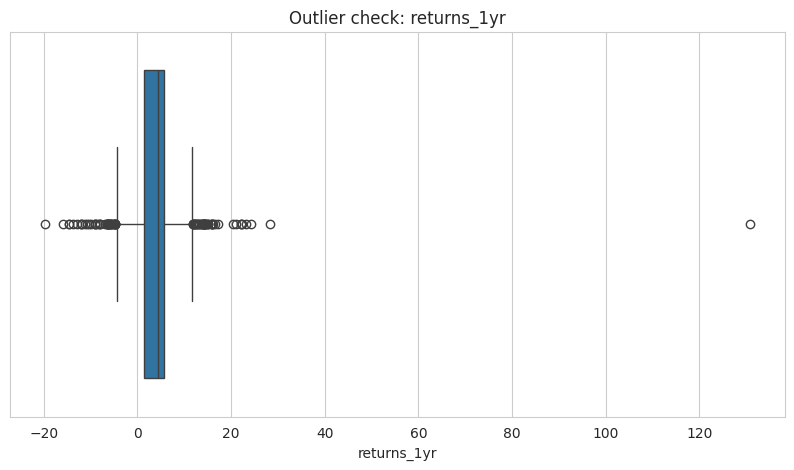

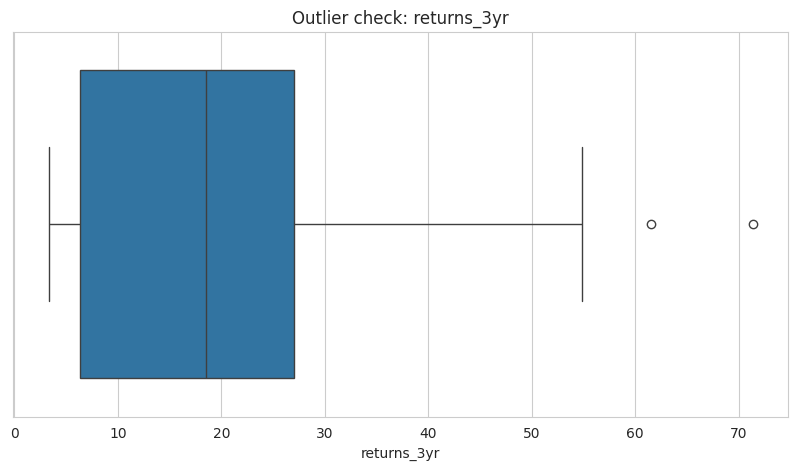

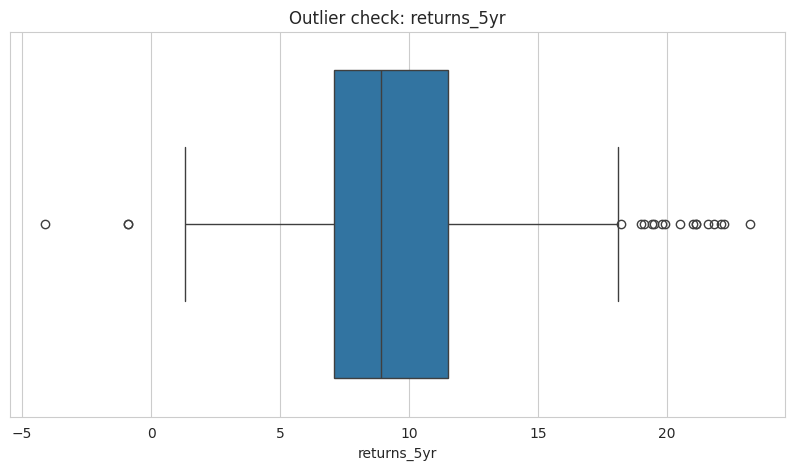

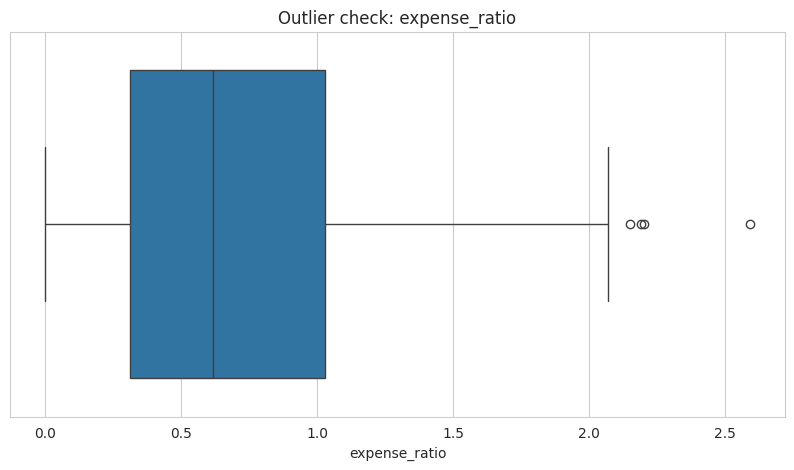

In [18]:
for col in ["returns_1yr", "returns_3yr", "returns_5yr", "expense_ratio"]:
    sns.boxplot(x=df_clean[col])
    plt.title(f"Outlier check: {col}")
    plt.show()



### Outlier Analysis: 1-Year Returns
The distribution of 1-year mutual fund returns exhibits significant right skewness, with the majority of funds clustered within a narrow return range and a small number of funds displaying extremely high or negative returns.  

A notable positive outlier is observed with returns exceeding 100%, indicating exceptional short-term performance. Such extreme values may arise due to sector-specific rallies, thematic exposure, or smaller fund sizes rather than consistent fund management skill.  

This behavior highlights the high volatility and noise inherent in short-term performance metrics. Consequently, 1-year returns alone are unreliable indicators of long-term fund performance and should be interpreted with caution.



From an investment and analytical perspective, the presence of extreme short-term outliers suggests that investors relying solely on recent performance may be exposed to heightened risk. Long-term returns and risk-adjusted measures provide a more stable and meaningful basis for evaluating mutual fund performance.



###Outlier Analysis: 3-Year Returns

The distribution of 3-year returns exhibits reduced skewness and fewer extreme outliers compared to 1-year returns. While some high-performing funds continue to stand out, the magnitude and frequency of extreme values are significantly lower.  

This indicates that short-term volatility effects diminish over longer investment horizons, resulting in more stable and reliable performance patterns. The upward shift in the median return further suggests that long-term investing smooths transient market fluctuations.
Comparing 1-year and 3-year return distributions demonstrates that short-term performance is heavily influenced by noise, whereas medium-term returns provide a more balanced reflection of fund performance. This reinforces the importance of evaluating mutual funds over longer horizons rather than relying on recent returns.


###Outlier Analysis: 5-Year Returns
The distribution of 5-year returns is notably more compact and symmetric compared to shorter investment horizons. Extreme outliers are substantially reduced, and the majority of funds cluster within a narrower performance range.  

This indicates that long-term investment horizons effectively smooth short-term market fluctuations, resulting in more stable and reliable performance outcomes. The reduced influence of extreme values suggests that sustained fund performance is less driven by transient market conditions and more by underlying fund strategy.

A comparative analysis of 1-year, 3-year, and 5-year return distributions reveals a clear pattern: short-term returns are highly volatile and prone to extreme values, while longer-term returns demonstrate increasing stability and reduced dispersion.  

This progression underscores the unreliability of short-term performance metrics for evaluating mutual funds and reinforces the importance of long-term and risk-adjusted measures in informed investment decision-making.


### Outlier Analysis: Expense Ratio
The distribution of expense ratios is right-skewed, with the majority of mutual funds charging moderate management fees and a small number of schemes exhibiting significantly higher expense ratios. Most funds fall within a narrow cost range, indicating competitive pricing across the industry.

While high expense ratio funds are relatively uncommon, their presence is important due to the compounding impact of costs on long-term returns. Elevated expense ratios must therefore be evaluated in conjunction with performance and risk-adjusted metrics, rather than in isolation.


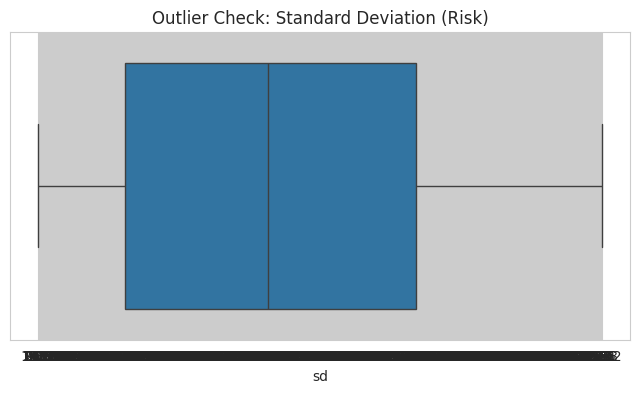

In [19]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["sd"])
plt.title("Outlier Check: Standard Deviation (Risk)")
plt.show()


The distribution of standard deviation values indicates substantial variability in risk levels across mutual fund schemes. Unlike short-term return distributions, the risk metric does not exhibit extreme skewness or isolated outliers, suggesting that volatility is more evenly distributed among funds.

This wide dispersion in volatility reflects the presence of multiple fund categories with distinct risk profiles. Higher standard deviation values do not inherently imply inferior fund performance, but rather indicate greater return variability, which must be evaluated alongside corresponding returns and risk-adjusted measures.


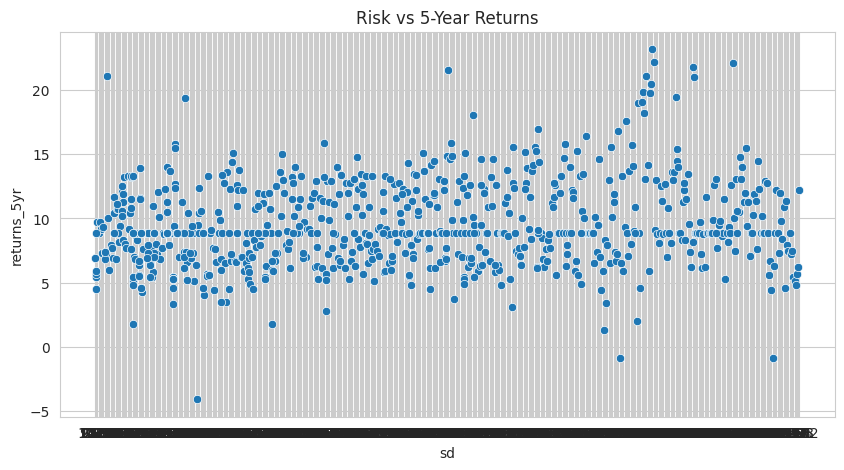

In [20]:
sns.scatterplot(data=df_clean, x="sd", y="returns_5yr")
plt.title("Risk vs 5-Year Returns")
plt.show()


The scatter plot indicates that higher risk, as measured by standard deviation, does not consistently translate into higher 5-year returns, suggesting that volatility alone is not a reliable predictor of long-term mutual fund performance.


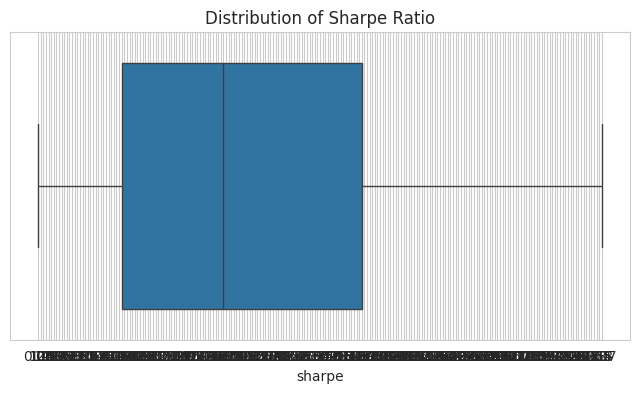

In [22]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["sharpe"])
plt.title("Distribution of Sharpe Ratio")
plt.show()


Funds with higher Sharpe ratios generally achieve superior 5-year returns, indicating that effective risk-adjusted performance is a stronger determinant of long-term success than volatility or raw returns alone.


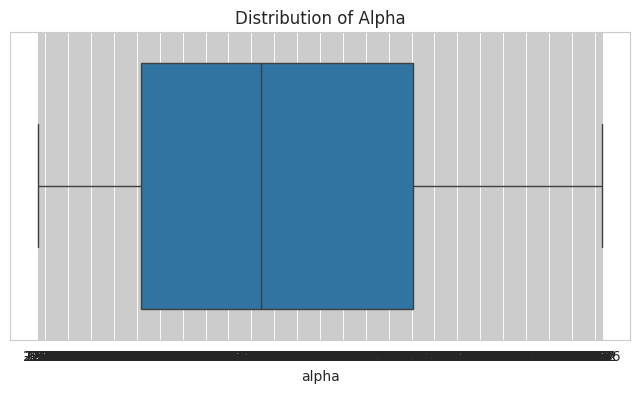

In [23]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["alpha"])
plt.title("Distribution of Alpha")
plt.show()


The distribution of alpha values is centered close to zero, with substantial dispersion on both the positive and negative sides. This suggests that while a small subset of funds demonstrates positive alpha, consistent benchmark outperformance is relatively uncommon across the broader mutual fund universe.

The results indicate that long-term mutual fund performance is driven more by market exposure and risk management than by persistent fund manager skill, reinforcing the difficulty of achieving sustained alpha.


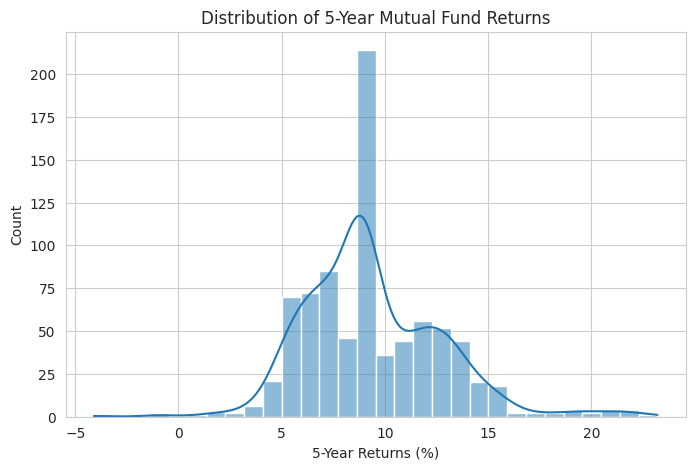

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["returns_5yr"], kde=True, bins=30)
plt.xlabel("5-Year Returns (%)")
plt.title("Distribution of 5-Year Mutual Fund Returns")
plt.show()


###Distribution Analysis: 5-Year Returns
The histogram and kernel density estimate of 5-year returns reveal a predominantly unimodal distribution with a slight right skew. The majority of mutual funds cluster around moderate long-term return levels, while a smaller number of funds achieve exceptionally high returns.
The right-skewed nature of the distribution indicates that while most funds deliver comparable long-term performance, a limited subset of schemes disproportionately contributes to higher return outcomes. This highlights the challenge of consistently identifying top-performing funds in advance.


In [25]:
df_clean["returns_5yr"].mean(), df_clean["returns_5yr"].median()


(np.float64(9.36953316953317), 8.9)

The mean return exceeds the median, reinforcing the presence of a right-skewed distribution influenced by a small number of high-performing funds.


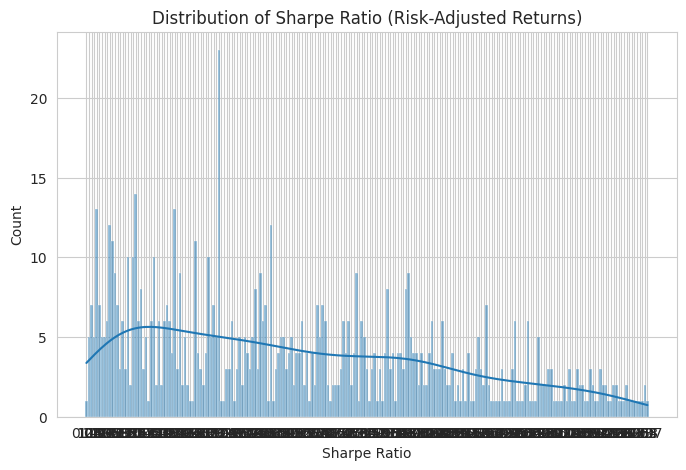

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["sharpe"], kde=True, bins=25)
plt.xlabel("Sharpe Ratio")
plt.title("Distribution of Sharpe Ratio (Risk-Adjusted Returns)")
plt.show()



The histogram and kernel density estimate of the Sharpe ratio indicate a right-skewed distribution centered around modest positive values. Most mutual funds deliver positive risk-adjusted returns, while only a small fraction achieve exceptionally high Sharpe ratios.


This distribution suggests that although risk-adjusted performance is generally positive across funds, superior efficiency in converting risk into returns is relatively uncommon. Consequently, distinguishing high-quality funds requires careful evaluation beyond average performance metrics.


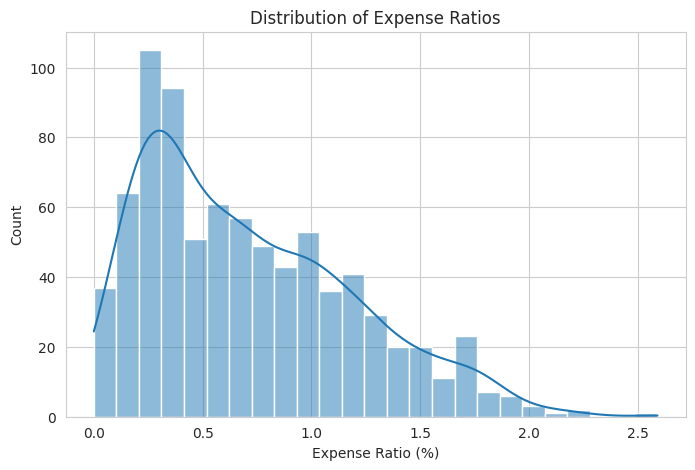

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["expense_ratio"], kde=True, bins=25)
plt.xlabel("Expense Ratio (%)")
plt.title("Distribution of Expense Ratios")
plt.show()


The expense ratio distribution exhibits strong right skewness, with a large concentration of mutual funds charging low to moderate fees. The density declines steadily as expense ratios increase, indicating that high-cost funds are relatively uncommon within the dataset.

Given that expense ratios represent a guaranteed and recurring cost, this distribution highlights the importance of cost efficiency in long-term investing. The presence of a small number of high-expense funds emphasizes the need to justify elevated costs through superior risk-adjusted performance or consistent alpha, both of which are shown to be rare.


# **Conclusion**

This exploratory data analysis examined mutual fund performance across multiple dimensions, including returns over different horizons, risk (volatility), cost structure, and risk-adjusted metrics such as the Sharpe ratio and alpha. The analysis reveals that short-term returns are highly volatile and prone to extreme values, making them unreliable indicators of sustained fund performance.

Long-term (5-year) returns exhibit greater stability, confirming that extended investment horizons reduce the influence of short-term market fluctuations. However, increased volatility does not consistently translate into higher long-term returns, indicating that risk alone is not a dependable driver of performance.

Risk-adjusted metrics provide deeper insight into fund quality. While most mutual funds generate positive Sharpe ratios, superior risk-adjusted performance is concentrated within a limited subset of schemes. Furthermore, alpha distributions are centered close to zero, suggesting that consistent benchmark outperformance through active management is relatively rare.

Expense ratios display a strong right-skewed distribution, with most funds charging moderate fees and a small number imposing significantly higher costs. Since expenses represent a certain and recurring drag on returns, their long-term impact is non-trivial and must be carefully considered.


The findings of this analysis have several important implications for investors. First, reliance on short-term performance metrics should be avoided, as they provide limited predictive value and may lead to suboptimal fund selection. Long-term performance and consistency are more reliable indicators of fund quality.

Second, volatility alone should not be interpreted as a proxy for superior returns. Investors should prioritize risk-adjusted measures, particularly the Sharpe ratio, which more effectively distinguishes high-quality funds from average performers.

Third, given the rarity of persistent positive alpha, investors should be cautious in assuming that active fund management consistently adds value. In many cases, broad market exposure combined with cost efficiency may offer comparable or superior outcomes.

Finally, expense ratios warrant careful scrutiny. Even modest differences in fees can compound significantly over time, reinforcing the importance of cost-aware investment decisions. High-cost funds should be evaluated critically and justified by demonstrably superior risk-adjusted performance.
